In [222]:
from ccka.models.kernel import KernelModel
from ccka.circuits.angleEmbeddingKernel import quackEmbeddingCircuit
from ccka.aligner.kta import fullKTA, centroidBasedKTA, quackKTA, randomKTA, greedyKTA
import pennylane as qml
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt 
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import time
import os
import warnings
warnings.filterwarnings("ignore")

In [223]:
def load_data(dataset_path):
    data = jnp.load(dataset_path, allow_pickle=True).item()
    X = jnp.asarray(data['x_train'])
    y = jnp.asarray(data['y_train'])
    x_test = jnp.asarray(data['x_test'])
    y_test = jnp.asarray(data['y_test'])

    X_combined = jnp.concatenate([X, x_test], axis=0)
    y_combined = jnp.concatenate([y, y_test], axis=0)

    return X_combined, y_combined

In [224]:
def run_experiment(dataset, dataset_path, centroids, num_iterations):

    print(f"Running centroidBasedKTA on {dataset} with centroids={centroids} and iterations={num_iterations}")
    
    X, y = load_data(dataset_path)

    kernel = quackEmbeddingCircuit(
                                num_qubits = 5,
                                reps = 6,
                                reupload = True
                        )
    init_weights = kernel.init_weights()
    model = KernelModel(circuit = kernel)

    aligner = centroidBasedKTA(
                    kernel_model= model,
                    data = X,
                    labels = y,
                    matrix_type='regular',
                    clustering='regular',
                    split_size=0.70,
                    centroids= centroids,
                    learning_rate=0.2,
                    centroid_lr=0.1,
                    sub_centroid_lr=0.1,
                    lambda_co=0.001,
                    lambda_kao=0.001,
                    epochs=num_iterations,
                    eps=0.001,
                    alpha=0.01
        )

    history = aligner.align()

    return history

In [225]:
result = run_experiment('Checkerboard', '../data/checkerboard_dataset.npy', 4, 100)

Running centroidBasedKTA on Checkerboard with centroids=4 and iterations=100


In [239]:
mc = [result['main_centroids'][0], result['main_centroids'][1], result['main_centroids'][2], result['main_centroids'][4]]
sc = [result['sub_centroids'][0], result['sub_centroids'][1], result['sub_centroids'][2], result['sub_centroids'][4]]
X, y = result['xtrain'], result['ytrain']
mc = np.array(mc)
sc = np.array(sc)
X = np.array(X)
y = np.array(y)

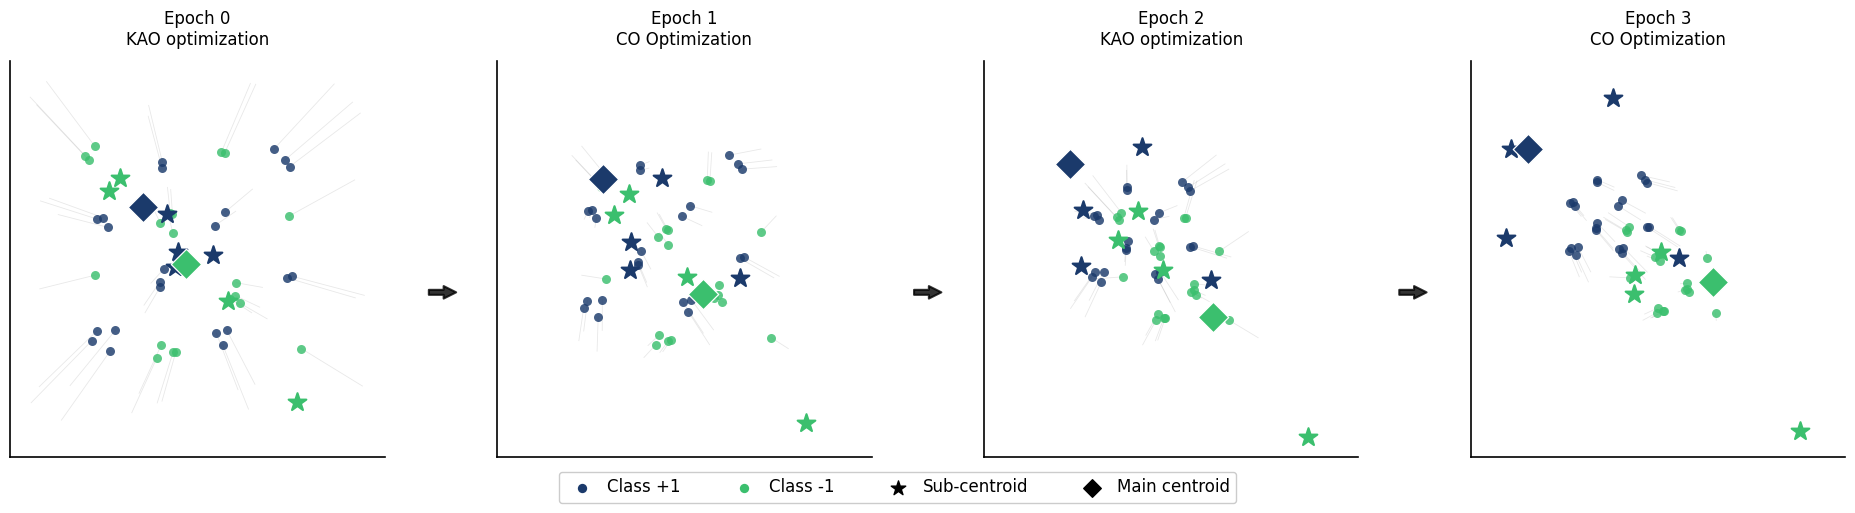

In [251]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.patches import FancyArrowPatch

# ─────────────────────────────────────────────────────────────────────────────
# ATTRACTION FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def sub_centroid_attraction(
    current_pos,
    y,
    current_sc,
    lr_sub=0.28
):

    new_pos = current_pos.copy()

    # class-wise sub-centroids
    sc_pos = current_sc[:4]
    sc_neg = current_sc[4:]

    for i in range(len(current_pos)):

        point = current_pos[i]

        # choose class-specific candidates
        if y[i] == 1:
            candidates = sc_pos
        else:
            candidates = sc_neg

        # distances to sub-centroids
        dists = np.linalg.norm(candidates - point, axis=1)

        # soft weighting
        weights = np.exp(-dists)
        weights /= np.sum(weights)

        # weighted target
        target = np.sum(
            candidates * weights[:, None],
            axis=0
        )

        # smooth directional movement
        direction = target - point
        distance = np.linalg.norm(direction)

        if distance > 1e-8:
            direction = direction / distance

        new_pos[i] += lr_sub * distance * direction

    return new_pos


def main_centroid_attraction(
    current_pos,
    y,
    current_mc,
    lr_main=0.12
):

    new_pos = current_pos.copy()

    for i in range(len(current_pos)):

        point = current_pos[i]

        # class-specific main centroid
        if y[i] == 1:
            target = current_mc[0]
        else:
            target = current_mc[1]

        # smooth movement
        direction = target - point
        distance = np.linalg.norm(direction)

        if distance > 1e-8:
            direction = direction / distance

        new_pos[i] += lr_main * distance * direction

    return new_pos


# ─────────────────────────────────────────────────────────────────────────────
# FONT / STYLE
# ─────────────────────────────────────────────────────────────────────────────

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = [
    'DejaVu Sans',
    'Liberation Sans',
    'Arial'
]

rcParams['mathtext.fontset'] = 'dejavusans'

# ─────────────────────────────────────────────────────────────────────────────
# COLOURS
# ─────────────────────────────────────────────────────────────────────────────

C_A = "#1B3A6B"
C_B = "#3BBF6E"

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    1,
    4,
    figsize=(24, 6),
    facecolor='white'
)

axes = np.ravel(axes)

# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL LIMITS
# ─────────────────────────────────────────────────────────────────────────────

pad = 0.05

xmin = min(
    np.min(X[:, 0]),
    np.min(mc[:, :, 0]),
    np.min(sc[:, :, 0])
) - pad

xmax = max(
    np.max(X[:, 0]),
    np.max(mc[:, :, 0]),
    np.max(sc[:, :, 0])
) + pad

ymin = min(
    np.min(X[:, 1]),
    np.min(mc[:, :, 1]),
    np.min(sc[:, :, 1])
) - pad

ymax = max(
    np.max(X[:, 1]),
    np.max(mc[:, :, 1]),
    np.max(sc[:, :, 1])
) + pad

# ─────────────────────────────────────────────────────────────────────────────
# EPOCHS
# ─────────────────────────────────────────────────────────────────────────────

epochs_to_plot = [0, 1, 2, 3]

# initial coordinates
current_coords = X.copy()

# ─────────────────────────────────────────────────────────────────────────────
# PLOTTING LOOP
# ─────────────────────────────────────────────────────────────────────────────

for panel, ax in enumerate(axes):

    # save previous positions for trajectories
    previous_coords = current_coords.copy()

    current_mc = mc[panel]
    current_sc = sc[panel]

    # alternating optimization dynamics
    if panel in [0, 2]:

        current_coords = sub_centroid_attraction(
            current_coords,
            y,
            current_sc,
            lr_sub=0.4
        )

    else:

        current_coords = main_centroid_attraction(
            current_coords,
            y,
            current_mc,
            lr_main=0.2
        )

    # ─────────────────────────────────────────────────────────────────────
    # AXIS STYLING
    # ─────────────────────────────────────────────────────────────────────

    ax.set_facecolor('white')

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_aspect('equal')

    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

    for sp in ['bottom', 'left']:
        ax.spines[sp].set_color('black')
        ax.spines[sp].set_linewidth(1.2)

    ax.set_xticks([])
    ax.set_yticks([])

    # ─────────────────────────────────────────────────────────────────────
    # TRAJECTORIES
    # ─────────────────────────────────────────────────────────────────────

    for i in range(len(current_coords)):

        ax.plot(
            [previous_coords[i, 0], current_coords[i, 0]],
            [previous_coords[i, 1], current_coords[i, 1]],
            color='gray',
            alpha=0.18,
            linewidth=0.6,
            zorder=1
        )

    # ─────────────────────────────────────────────────────────────────────
    # DATA POINTS
    # ─────────────────────────────────────────────────────────────────────

    ax.scatter(
        current_coords[y == 1, 0],
        current_coords[y == 1, 1],
        s=42,
        color=C_A,
        zorder=2,
        linewidths=0,
        alpha=0.82
    )

    ax.scatter(
        current_coords[y == -1, 0],
        current_coords[y == -1, 1],
        s=42,
        color=C_B,
        zorder=2,
        linewidths=0,
        alpha=0.82
    )

    # ─────────────────────────────────────────────────────────────────────
    # SUB-CENTROIDS
    # ─────────────────────────────────────────────────────────────────────

    ax.scatter(
        current_sc[:4, 0],
        current_sc[:4, 1],
        s=180,
        marker='*',
        color=C_A,
        linewidths=1.5,
        zorder=4
    )

    ax.scatter(
        current_sc[4:, 0],
        current_sc[4:, 1],
        s=180,
        marker='*',
        color=C_B,
        linewidths=1.5,
        zorder=4
    )

    # ─────────────────────────────────────────────────────────────────────
    # MAIN CENTROIDS
    # ─────────────────────────────────────────────────────────────────────

    ax.scatter(
        current_mc[0, 0],
        current_mc[0, 1],
        s=240,
        marker='D',
        color=C_A,
        edgecolors='white',
        linewidths=0.9,
        zorder=5
    )

    ax.scatter(
        current_mc[1, 0],
        current_mc[1, 1],
        s=240,
        marker='D',
        color=C_B,
        edgecolors='white',
        linewidths=0.9,
        zorder=5
    )

    # ─────────────────────────────────────────────────────────────────────
    # TITLES
    # ─────────────────────────────────────────────────────────────────────

    if panel in [0, 2]:
        title = f"Epoch {epochs_to_plot[panel]}\nKAO optimization"
    else:
        title = f"Epoch {epochs_to_plot[panel]}\nCO Optimization"

    ax.set_title(
        title,
        fontsize=12,
        pad=12
    )

# ─────────────────────────────────────────────────────────────
# ARROWS BETWEEN PANELS
# ─────────────────────────────────────────────────────────────

for i in range(len(axes) - 1):

    # current axis
    ax1 = axes[i]

    # next axis
    ax2 = axes[i + 1]

    # positions in figure coordinates
    pos1 = ax1.get_position()
    pos2 = ax2.get_position()

    # arrow start/end
    start = (
        pos1.x1 + 0.01,
        (pos1.y0 + pos1.y1) / 2
    )

    end = (
        pos2.x0 - 0.01,
        (pos2.y0 + pos2.y1) / 2
    )

    arrow = FancyArrowPatch(
        start,
        end,
        transform=fig.transFigure,
        arrowstyle='simple',
        mutation_scale=18,
        linewidth=1.5,
        color='black',
        alpha=0.8
    )

    fig.add_artist(arrow)


# ─────────────────────────────────────────────────────────────────────────────
# LEGEND
# ─────────────────────────────────────────────────────────────────────────────

leg_handles = [

    plt.scatter(
        [], [],
        s=45,
        color=C_A,
        linewidths=0,
        label="Class +1"
    ),

    plt.scatter(
        [], [],
        s=45,
        color=C_B,
        linewidths=0,
        label="Class -1"
    ),

    plt.scatter(
        [], [],
        s=120,
        marker='*',
        color='black',
        label="Sub-centroid"
    ),

    plt.scatter(
        [], [],
        s=80,
        marker='D',
        color='black',
        label="Main centroid"
    ),
]

fig.legend(
    handles=leg_handles,
    loc='lower center',
    ncol=4,
    fontsize=12,
    frameon=True,
    framealpha=1.0,
    edgecolor='#CCCCCC',
    bbox_to_anchor=(0.5, 0.13),
    columnspacing=2.8,
    handletextpad=0.5
)

# ─────────────────────────────────────────────────────────────────────────────
# LAYOUT
# ─────────────────────────────────────────────────────────────────────────────

plt.subplots_adjust(
    wspace=0.22,
    bottom=0.22
)

plt.show()
fig.savefig('optimization_dynamics.png', dpi=600, bbox_inches='tight')